# Задание

## 1. Самостоятельно выбрать датасет на любую тему, который будет содержать числовые и категориальные переменные;
## 2. Очистить данные от дубликатов, выбросов и т.д.;
## 3. Провести разведовательный анализ данных с выводом описательных статистик, визуализаций и функции groupby, описать полученные выводы;

ТИТАНИК: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ

Размер датасета: (891, 12)
Количество строк: 891
Количество столбцов: 12

Первые 5 строк датасета:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282

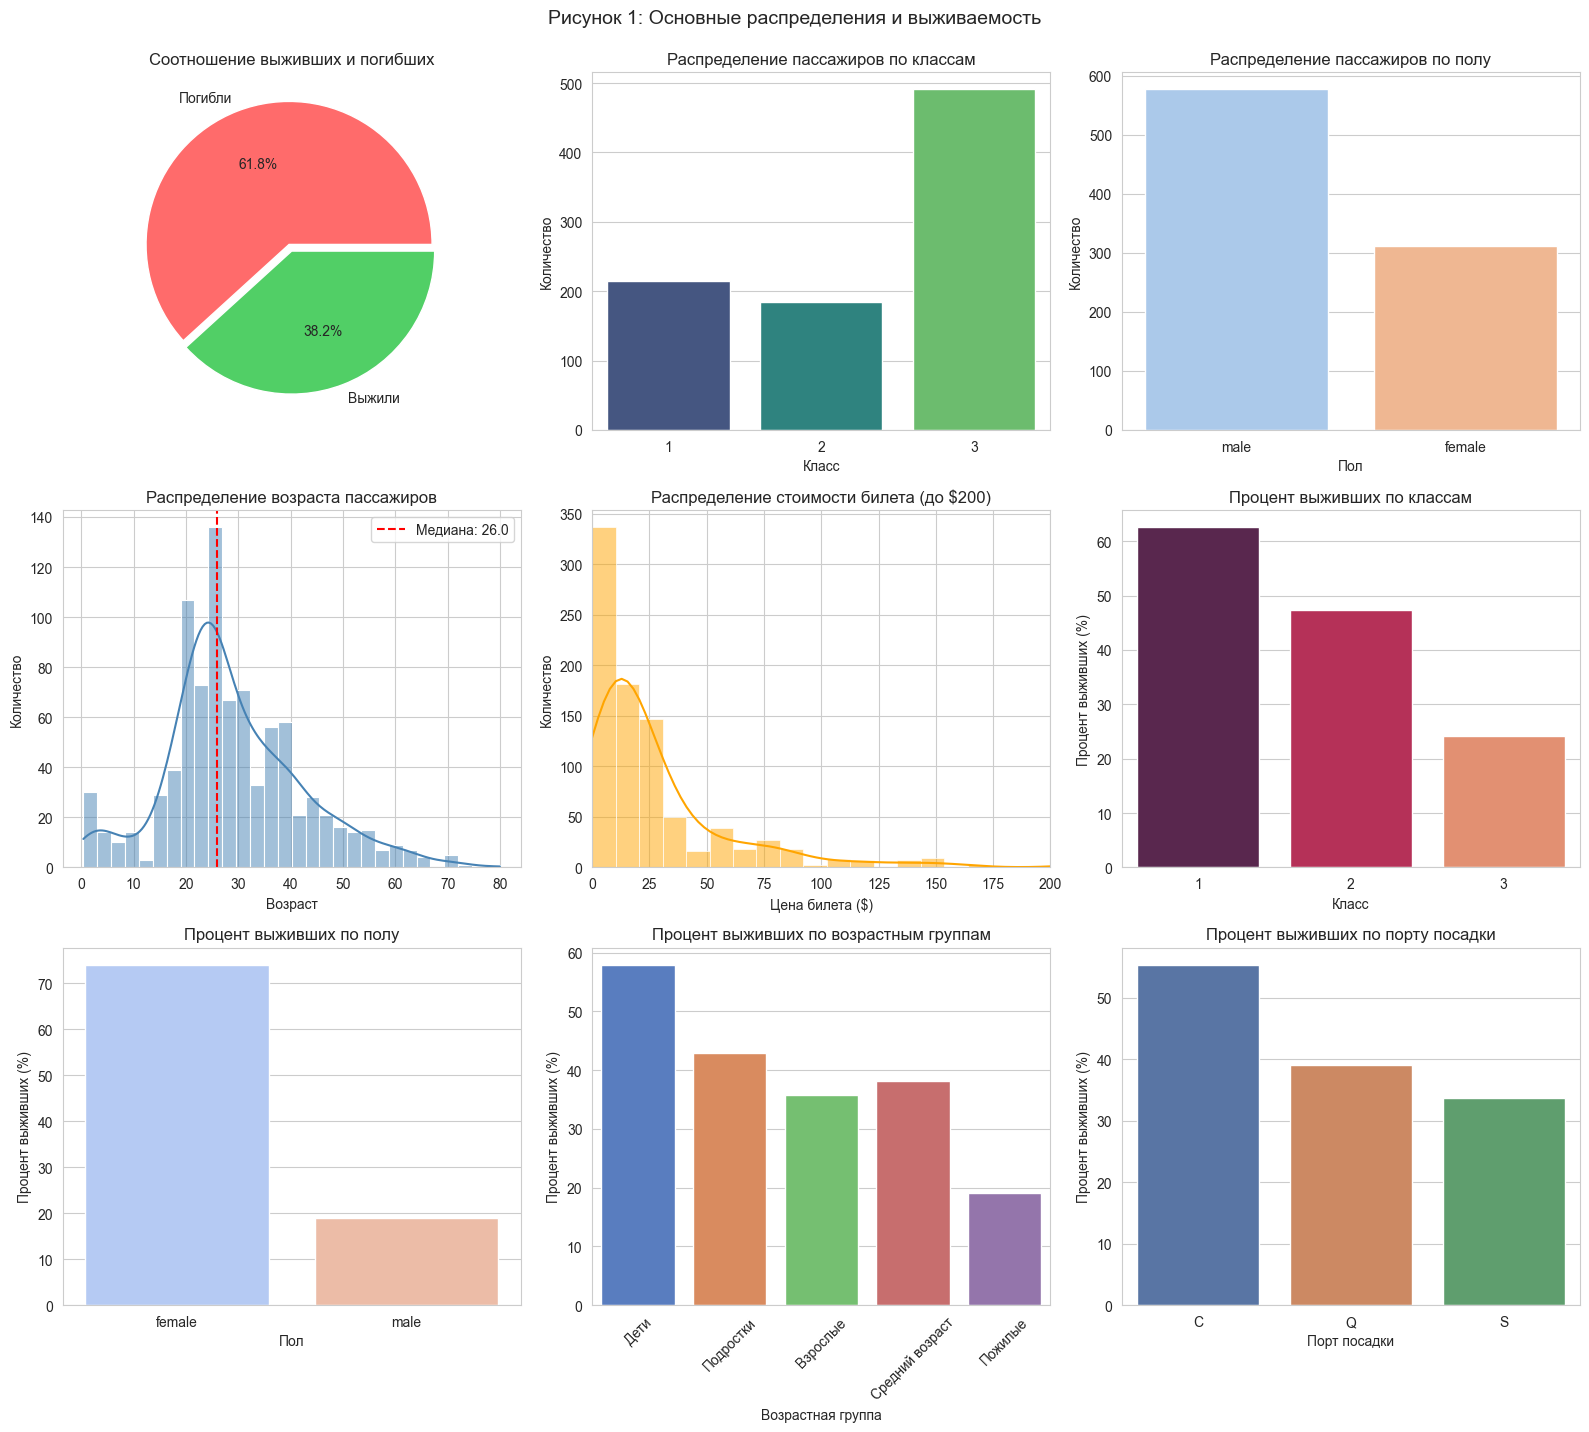

5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


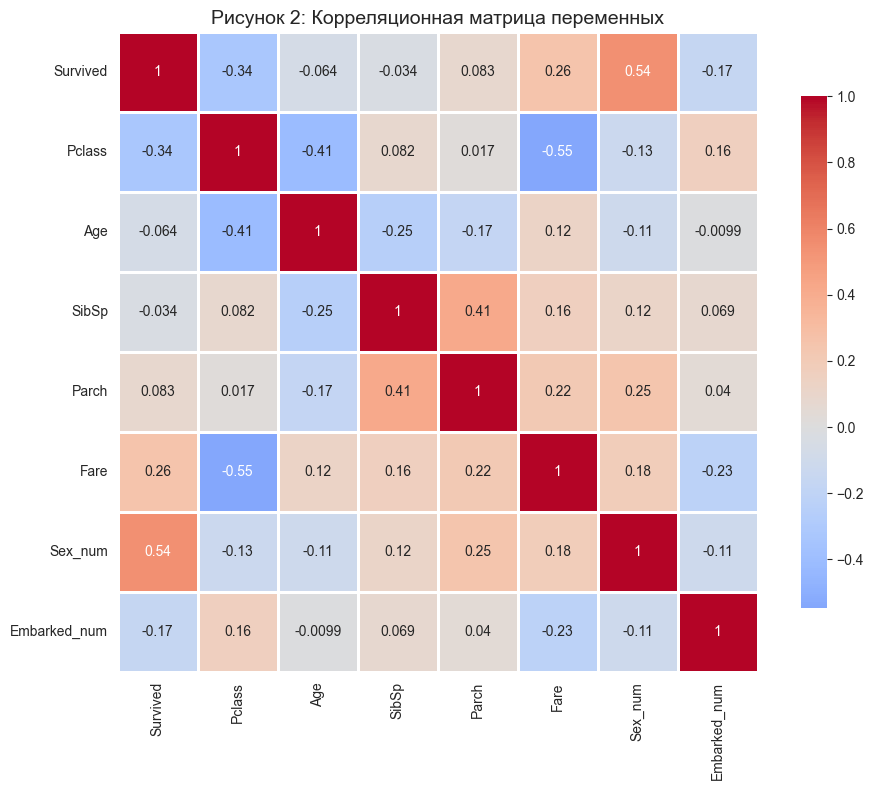


Наиболее сильные корреляции с выживаемостью (Survived):
  Sex_num: 0.542
  Fare: 0.255
  Parch: 0.083
  SibSp: -0.034
  Age: -0.064
  Embarked_num: -0.170
  Pclass: -0.336
6. АНАЛИЗ С ИСПОЛЬЗОВАНИЕМ GROUPBY

6.1 Выживаемость по классу и полу:
               Процент выживших (%)  Количество
Pclass Sex                                     
1      female                  96.7          92
       male                    36.9         122
2      female                  92.1          76
       male                    15.7         108
3      female                  50.0         144
       male                    13.5         347


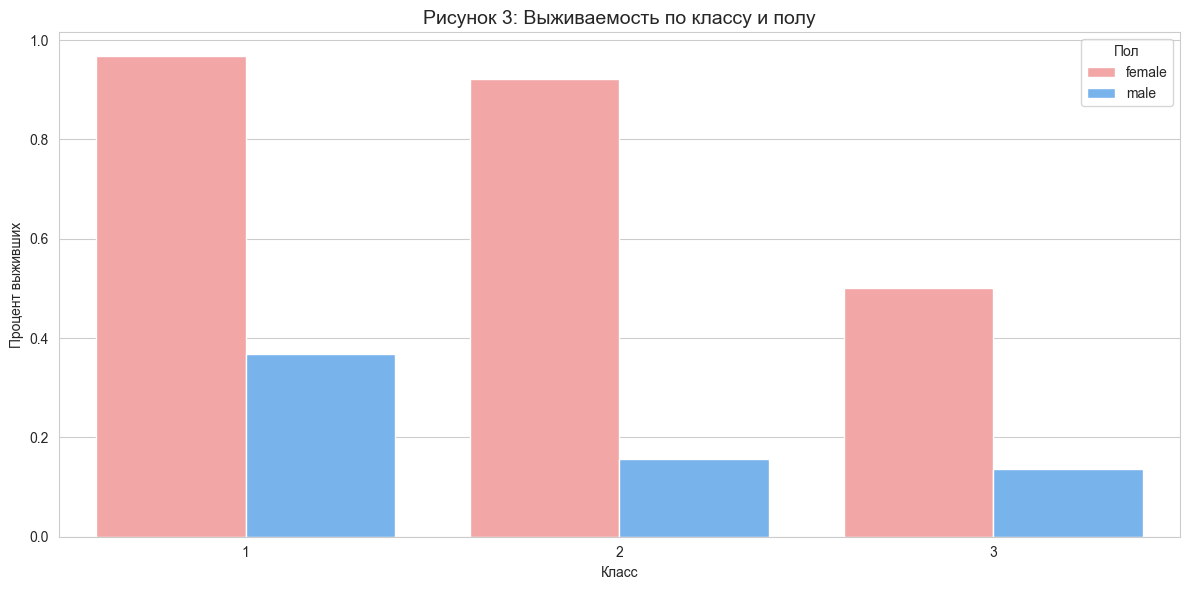


6.2 Средние показатели по классам:
          Age          Fare        Survived      
         mean median   mean median     mean count
Pclass                                           
1       38.16   38.0  84.19  58.69     0.63   214
2       29.86   30.0  20.66  14.25     0.47   184
3       24.80   25.0  13.68   8.05     0.24   491

6.3 Анализ по порту посадки:
          Выживаемость  Количество  Ср. цена  Мед. цена  Процент 1 класса
Embarked                                                                 
C                 55.4         168    59.954      29.70             0.506
Q                 39.0          77    13.276       7.75             0.026
S                 33.7         644    27.080      13.00             0.197

6.4 Влияние семьи на выживаемость:
            Выживаемость (%)  Количество
FamilySize                              
1                       30.1         535
2                       55.3         161
3                       57.8         102
4                      

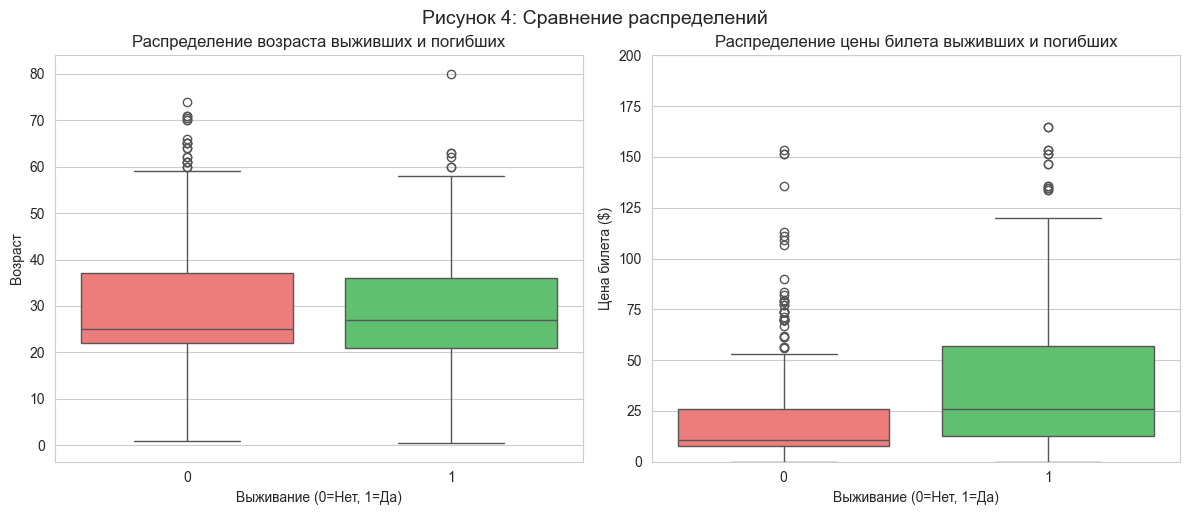

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("husl"))
plt.rcParams['figure.figsize'] = (12, 8)

df = pd.read_csv('train.csv')

print("ТИТАНИК: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ")

print(f"\nРазмер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

print("\nПервые 5 строк датасета:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика по числовым данным:")
print(df.describe())

print("\nСтатистика по категориальным данным:")
print(df.describe(include=['object']))

print("2. ОЧИСТКА ДАННЫХ")

print(f"\nКоличество дубликатов: {df.duplicated().sum()}")

print("\nПропущенные значения по колонкам:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент': missing_percent
})
print(missing_df[missing_df['Пропущено'] > 0])

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print("\nПропуски в Age заполнены медианным значением по группе Pclass-Sex")

df['Cabin'] = df['Cabin'].fillna('Unknown')
print("Пропуски в Cabin заменены на 'Unknown'")

df = df.dropna(subset=['Embarked'])
print("Удалены строки с пропущенными значениями в Embarked")

print("\nПроверка на выбросы:")

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in numeric_cols:
    outliers_count, lb, ub = detect_outliers(df, col)
    print(f"{col}: {outliers_count} выбросов (границы: [{lb:.2f}, {ub:.2f}])")

print("\nОчистка данных завершена!")
print(f"Размер датасета после очистки: {df.shape}")

print("3. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ")

print("\n3.1 Описательная статистика после очистки:")

print("\nЧисловые переменные:")
print(df[['Age', 'Fare', 'SibSp', 'Parch']].describe())

print("\nКатегориальные переменные:")
print(df[['Sex', 'Embarked', 'Pclass']].describe())

print("4. ВИЗУАЛИЗАЦИЯ ДАННЫХ")
fig = plt.figure(figsize=(16, 14))

ax1 = fig.add_subplot(3, 3, 1)
survived_counts = df['Survived'].value_counts()
ax1.pie(survived_counts.values, labels=['Погибли', 'Выжили'], 
        autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], explode=(0.05, 0))
ax1.set_title('Соотношение выживших и погибших', fontsize=12)

ax2 = fig.add_subplot(3, 3, 2)
sns.countplot(data=df, x='Pclass', palette='viridis', ax=ax2)
ax2.set_title('Распределение пассажиров по классам', fontsize=12)
ax2.set_xlabel('Класс')
ax2.set_ylabel('Количество')

ax3 = fig.add_subplot(3, 3, 3)
sns.countplot(data=df, x='Sex', palette='pastel', ax=ax3)
ax3.set_title('Распределение пассажиров по полу', fontsize=12)
ax3.set_xlabel('Пол')
ax3.set_ylabel('Количество')

ax4 = fig.add_subplot(3, 3, 4)
sns.histplot(data=df, x='Age', bins=30, kde=True, color='steelblue', ax=ax4)
ax4.axvline(df['Age'].median(), color='red', linestyle='--', label=f'Медиана: {df["Age"].median():.1f}')
ax4.set_title('Распределение возраста пассажиров', fontsize=12)
ax4.set_xlabel('Возраст')
ax4.set_ylabel('Количество')
ax4.legend()

ax5 = fig.add_subplot(3, 3, 5)
sns.histplot(data=df, x='Fare', bins=50, kde=True, color='orange', ax=ax5)
ax5.set_xlim(0, 200)
ax5.set_title('Распределение стоимости билета (до $200)', fontsize=12)
ax5.set_xlabel('Цена билета ($)')
ax5.set_ylabel('Количество')

ax6 = fig.add_subplot(3, 3, 6)
survival_by_class = df.groupby('Pclass')['Survived'].mean().mul(100).round(1)
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, palette='rocket', ax=ax6)
ax6.set_title('Процент выживших по классам', fontsize=12)
ax6.set_xlabel('Класс')
ax6.set_ylabel('Процент выживших (%)')

ax7 = fig.add_subplot(3, 3, 7)
survival_by_sex = df.groupby('Sex')['Survived'].mean().mul(100).round(1)
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, palette='coolwarm', ax=ax7)
ax7.set_title('Процент выживших по полу', fontsize=12)
ax7.set_xlabel('Пол')
ax7.set_ylabel('Процент выживших (%)')

ax8 = fig.add_subplot(3, 3, 8)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Дети', 'Подростки', 'Взрослые', 'Средний возраст', 'Пожилые'])
survival_by_age = df.groupby('AgeGroup')['Survived'].mean().mul(100)
sns.barplot(x=survival_by_age.index, y=survival_by_age.values, palette='muted', ax=ax8)
ax8.set_title('Процент выживших по возрастным группам', fontsize=12)
ax8.set_xlabel('Возрастная группа')
ax8.set_ylabel('Процент выживших (%)')
ax8.tick_params(axis='x', rotation=45)

ax9 = fig.add_subplot(3, 3, 9)
survival_by_embarked = df.groupby('Embarked')['Survived'].mean().mul(100).round(1)
sns.barplot(x=survival_by_embarked.index, y=survival_by_embarked.values, palette='deep', ax=ax9)
ax9.set_title('Процент выживших по порту посадки', fontsize=12)
ax9.set_xlabel('Порт посадки')
ax9.set_ylabel('Процент выживших (%)')

plt.tight_layout()
plt.suptitle('Рисунок 1: Основные распределения и выживаемость', fontsize=14, y=1.02)
plt.show()

print("5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")

df_corr = df.copy()
df_corr['Sex_num'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked_num'] = df_corr['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

numeric_cols_for_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_num', 'Embarked_num']
corr_matrix = df_corr[numeric_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Рисунок 2: Корреляционная матрица переменных', fontsize=14)
plt.tight_layout()
plt.show()

print("\nНаиболее сильные корреляции с выживаемостью (Survived):")
surv_corr = corr_matrix['Survived'].drop('Survived').sort_values(ascending=False)
for var, corr in surv_corr.items():
    print(f"  {var}: {corr:.3f}")

print("6. АНАЛИЗ С ИСПОЛЬЗОВАНИЕМ GROUPBY")
print("\n6.1 Выживаемость по классу и полу:")
survival_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].agg(['mean', 'count']).round(3)
survival_class_sex['mean'] = survival_class_sex['mean'] * 100
survival_class_sex.columns = ['Процент выживших (%)', 'Количество']
print(survival_class_sex)

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', 
            palette=['#ff9999', '#66b3ff'], ci=None)
plt.title('Рисунок 3: Выживаемость по классу и полу', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Процент выживших')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

print("\n6.2 Средние показатели по классам:")
class_stats = df.groupby('Pclass')[['Age', 'Fare', 'Survived']].agg({
    'Age': ['mean', 'median'],
    'Fare': ['mean', 'median'],
    'Survived': ['mean', 'count']
}).round(2)
print(class_stats)

print("\n6.3 Анализ по порту посадки:")
port_stats = df.groupby('Embarked').agg({
    'Survived': ['mean', 'count'],
    'Fare': ['mean', 'median'],
    'Pclass': lambda x: (x == 1).mean() 
}).round(3)
port_stats.columns = ['Выживаемость', 'Количество', 'Ср. цена', 'Мед. цена', 'Процент 1 класса']
port_stats['Выживаемость'] = port_stats['Выживаемость'] * 100
print(port_stats)

print("\n6.4 Влияние семьи на выживаемость:")
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
family_stats = df.groupby('FamilySize')['Survived'].agg(['mean', 'count']).round(3)
family_stats['mean'] = family_stats['mean'] * 100
family_stats.columns = ['Выживаемость (%)', 'Количество']
print(family_stats)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Survived', y='Age', palette=['#ff6b6b', '#51cf66'])
plt.xlabel('Выживание (0=Нет, 1=Да)')
plt.ylabel('Возраст')
plt.title('Распределение возраста выживших и погибших')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Survived', y='Fare', palette=['#ff6b6b', '#51cf66'])
plt.xlabel('Выживание (0=Нет, 1=Да)')
plt.ylabel('Цена билета ($)')
plt.ylim(0, 200)
plt.title('Распределение цены билета выживших и погибших')

plt.tight_layout()
plt.suptitle('Рисунок 4: Сравнение распределений', fontsize=14, y=1.02)
plt.show()